# Gaussian Process Regression — 회귀 적합 및 유의성 검정

## 방법론
- **ARD 커널** (Automatic Relevance Determination): 각 특성(평량, BET)에 독립적인 length scale 부여
- **유의성 기준**: Log Marginal Likelihood (LML) 비교 검정
  - ΔlogLML = logLML(전체모델) − logLML(해당 특성 제거 모델)
  - ΔlogLML > 3 nats → 유의 (Jeffreys' scale 기준 "strong evidence")
  - 1 ≤ ΔlogLML < 3 → 경계
  - ΔlogLML < 1 → 비유의
- **ARD length scale**: 값이 클수록 해당 특성에 무감 → 기여도 낮음
- 모든 적합은 전체 9개 데이터로 수행 (in-sample fitting)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, WhiteKernel, ConstantKernel as C
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from mpl_toolkits.mplot3d import Axes3D

In [2]:
# 폰트 설정
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"  
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

## 데이터 로드 및 전처리

In [3]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [10]:
df = pd.read_excel('./datasets/swatch.xlsx')

cols    = df.columns
col_GD  = cols[3]   # 'SWATCH(GD) 24h(Con)'
col_HD  = cols[4]   # 'SWATCH(HD) 24h(Con)'
feat_names = [cols[1], cols[2]]   # ['평량(g/m2)', 'BET(m2/g)']

df['log_GD'] = np.log(df[col_GD])
df['log_HD'] = np.log(df[col_HD])

df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),log_GD,log_HD
0,ACF25-01,105.20,1150,320,280,5.768321,5.634790
1,ACF25-02,99.30,1450,470,220,6.152733,5.393628
2,ACF25-03,119.70,1150,1150,550,7.047517,6.309918
3,ACF25-04,110.40,1300,850,850,6.745236,6.745236
4,ACF25-05,103.44,1016,470,580,6.152733,6.363028
5,ACF25-06,122.83,1080,20,140,2.995732,4.941642
6,ACF25-07,154.49,1139,380,10,5.940171,2.302585
7,ACF25-08,140.00,1300,20,5,2.995732,1.609438
8,ACF25-09,130.00,2197,50,5,3.912023,1.609438


## 헬퍼 함수

In [75]:
def fit_gpr(X_sc, y, n_restarts=20, seed=42):
    """
    ARD RBF + WhiteKernel 으로 GPR 적합 (전체 데이터).
    ARD: 각 특성에 독립적인 length_scale → 기여도 분리 가능.
    """
    n_feat = X_sc.shape[1]
    kernel = (
        C(1.0, (1e-3, 1e3))
        * RBF(length_scale=np.ones(n_feat),
              length_scale_bounds=[(1e-2, 1e3)] * n_feat)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e3))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=seed
    )
    gpr.fit(X_sc, y)
    return gpr


def fit_gpr_reduced(X_sc, y, n_restarts=20, seed=42):
    """1D ARD GPR 적합 (특성 1개 제거된 데이터)."""
    kernel = (
        C(1.0, (1e-3, 1e3))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e3))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=seed
    )
    gpr.fit(X_sc, y)
    return gpr


def significance_test(X_sc, y, feat_names, n_restarts=20):
    """
    LML 기반 유의성 검정.
    ΔlogLML = logLML(전체) − logLML(특성 i 제거)
    Jeffreys scale: >3 → 유의, 1~3 → 경계, <1 → 비유의
    """
    gpr_full = fit_gpr(X_sc, y, n_restarts)
    lml_full = gpr_full.log_marginal_likelihood_value_

    # ARD length scales 추출
    ls = gpr_full.kernel_.k1.k2.length_scale   # [l_feat1, l_feat2]
    relevance = (1.0 / ls) / (1.0 / ls).sum() * 100  # 기여도 %

    rows = []
    for i, fname in enumerate(feat_names):
        idx = [j for j in range(len(feat_names)) if j != i]
        gpr_red = fit_gpr_reduced(X_sc[:, idx], y, n_restarts)
        lml_red = gpr_red.log_marginal_likelihood_value_
        delta   = lml_full - lml_red

        if delta >= 3:
            sig = '*** (유의)'
        elif delta >= 1:
            sig = '*   (경계)'
        else:
            sig = '    (비유의)'

        rows.append({
            '특성':            fname,
            'ARD length scale': round(ls[i], 4),
            '기여도 (%)':       round(relevance[i], 2),
            'logLML (전체)':    round(lml_full, 4),
            'logLML (제거 후)': round(lml_red, 4),
            'ΔlogLML':         round(delta, 4),
            '유의성':           sig
        })

    noise = gpr_full.kernel_.k2.noise_level
    signal = gpr_full.kernel_.k1.k1.constant_value

    return pd.DataFrame(rows), gpr_full, lml_full, ls, noise, signal


def plot_fit_and_surface(gpr_full, X_sc, X_raw, y, scaler,
                         feat_names, y_label, log_y=False):
    """
    (1) 적합값 vs 실측값  (2) 응답 표면 등고선
    """
    # --- 적합값 (in-sample) ---
    y_fit, y_std = gpr_full.predict(X_sc, return_std=True)

    if log_y:
        y_plot_true = np.exp(y)
        y_plot_fit  = np.exp(y_fit)
        y_lo = np.exp(y_fit - 1.96 * y_std)
        y_hi = np.exp(y_fit + 1.96 * y_std)
        y_err = [y_plot_fit - y_lo, y_hi - y_plot_fit]
        rmse = np.sqrt(mean_squared_error(y_plot_true, y_plot_fit))
        r2   = r2_score(y_plot_true, y_plot_fit)
    else:
        y_plot_true = y
        y_plot_fit  = y_fit
        y_err = 1.96 * y_std
        rmse = np.sqrt(mean_squared_error(y, y_fit))
        r2   = r2_score(y, y_fit)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- 패널 1: Fitted vs Observed ---
    ax = axes[0]
    ax.errorbar(y_plot_true, y_plot_fit, yerr=y_err,
                fmt='o', color='steelblue', ecolor='lightblue',
                elinewidth=2, capsize=4, markersize=7)
    lo = min(y_plot_true.min(), y_plot_fit.min())
    hi = max(y_plot_true.max(), y_plot_fit.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Fitted')
    unit = '(exp scale)' if log_y else ''
    ax.set_title(f'Fitted vs Observed {unit} \nR^2={r2:.2f}')

    # --- 패널 2: 응답 표면 ---
    ax2 = axes[1]
    # ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    
    n_grid = 60
    x1_range = np.linspace(X_raw[:, 0].min() * 0.95, X_raw[:, 0].max() * 1.05, n_grid)
    x2_range = np.linspace(X_raw[:, 1].min() * 0.95, X_raw[:, 1].max() * 1.05, n_grid)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    X_grid_raw = np.c_[xx1.ravel(), xx2.ravel()]
    X_grid_sc  = scaler.transform(X_grid_raw)
    zz = gpr_full.predict(X_grid_sc).reshape(n_grid, n_grid)
    if log_y:
        zz = np.exp(zz)

    cp = ax2.contourf(xx1, xx2, zz, levels=20, cmap='RdYlGn')
    plt.colorbar(cp, ax=ax2, label=y_label)
    ax2.scatter(X_raw[:, 0], X_raw[:, 1], c='black', s=60, zorder=5)
    ax2.set_xlabel(feat_names[0])
    ax2.set_ylabel(feat_names[1])
    ax2.set_title(f'Response Surface\n{y_label}')

    plt.tight_layout()
    plt.show()

    return rmse, r2


def run_analysis(X_raw, y, y_label, feat_names, log_y=False, n_restarts=20):
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_raw)

    print('=' * 60)
    print(f'  목표 변수: {y_label}')
    print('=' * 60)

    # 유의성 검정
    sig_df, gpr_full, lml_full, ls, noise, signal = significance_test(
        X_sc, y, feat_names, n_restarts
    )

    print(f'\n[커널 파라미터 (최적화 후)]')
    print(f'  Signal variance (σ²) : {signal:.4f}')
    print(f'  Noise level (σ²_n)   : {noise:.4f}')
    print(f'  SNR                  : {signal / noise:.2f}')
    print(f'  log Marginal Likelihood (전체 모델): {lml_full:.4f}')

    print(f'\n[특성 유의성 검정]')
    display(sig_df)

    # 플롯
    rmse, r2 = plot_fit_and_surface(
        gpr_full, X_sc, X_raw, y, scaler, feat_names, y_label, log_y
    )

    return {'gpr': gpr_full, 'scaler': scaler, 'sig_df': sig_df,
            'rmse': rmse, 'r2': r2, 'lml': lml_full}

---
### 해석 가이드

| 지표 | 의미 |
|---|---|
| **ARD length scale (l)** | 작을수록 해당 특성 변화에 민감 → 기여도 높음 |
| **기여도 (%)** | 1/l 의 상대 비율. 두 특성의 상대적 중요도 |
| **ΔlogLML** | 해당 특성 제거 시 모델 설명력 감소량 (nats) |
| **SNR** | Signal / Noise 비율. 높을수록 신호가 노이즈보다 강함 |
| **R² (in-sample)** | 적합도. GPR은 보간하므로 1에 가까움 |

> **주의**: in-sample R²는 GPR이 훈련 데이터를 보간하는 경향이 있어 1에 가까울 수 있습니다.  
> 유의성 판단은 **ΔlogLML** 과 **ARD length scale** 을 기준으로 합니다.

---
## 1. GD 방호성능 — 원값

  목표 변수: SWATCH(GD) 24h(Con)

[커널 파라미터 (최적화 후)]
  Signal variance (σ²) : 0.5456
  Noise level (σ²_n)   : 0.4544
  SNR                  : 1.20
  log Marginal Likelihood (전체 모델): -12.7704

[특성 유의성 검정]


,특성,ARD length scale,기여도 (%),logLML (전체),logLML (제거 후),ΔlogLML,유의성
0,평량(g/m2),0.01,50.0,-12.7704,-12.7723,0.0018,(비유의)
1,BET(m2/g),0.01,50.0,-12.7704,-12.7704,0.0000,(비유의)


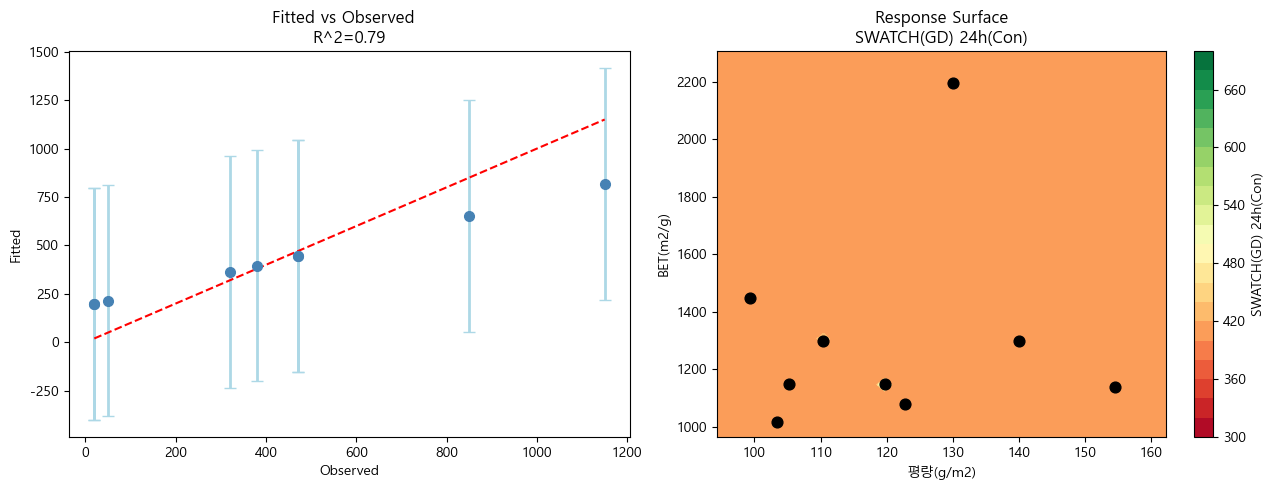

In [76]:
X_raw = df[[cols[1], cols[2]]].values
y_GD  = df[col_GD].values

res_GD = run_analysis(X_raw, y_GD, col_GD, feat_names, log_y=False)

---
## 2. GD 방호성능 — 로그 변환

  목표 변수: log_GD

[커널 파라미터 (최적화 후)]
  Signal variance (σ²) : 0.2919
  Noise level (σ²_n)   : 0.7296
  SNR                  : 0.40
  log Marginal Likelihood (전체 모델): -12.5961

[특성 유의성 검정]


,특성,ARD length scale,기여도 (%),logLML (전체),logLML (제거 후),ΔlogLML,유의성
0,평량(g/m2),0.6104,99.94,-12.5961,-12.7711,0.175,(비유의)
1,BET(m2/g),1000.0000,0.06,-12.5961,-12.5961,-0.000,(비유의)


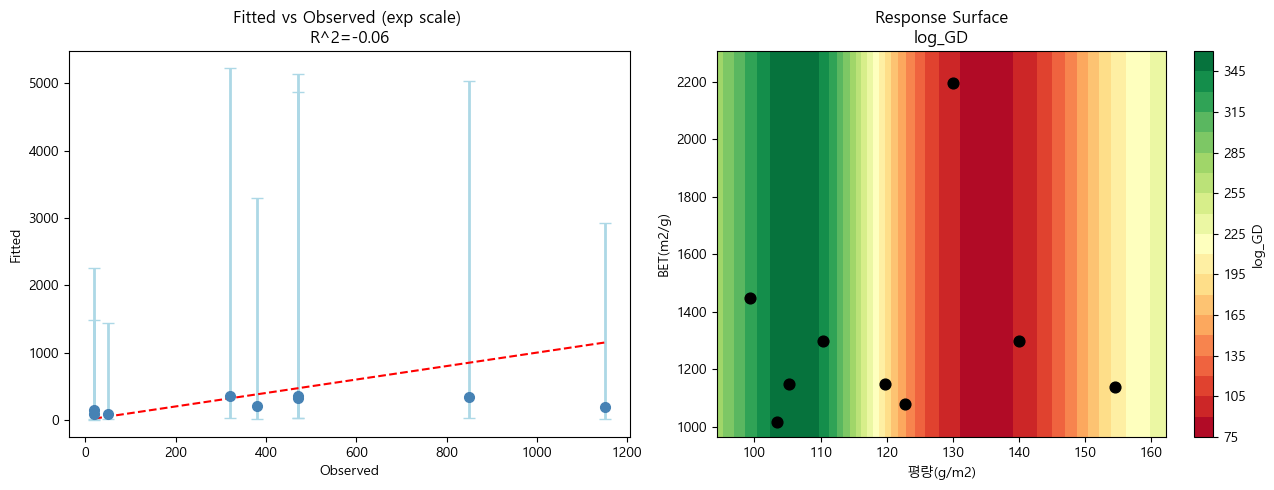

In [77]:
y_logGD = df['log_GD'].values

res_logGD = run_analysis(X_raw, y_logGD, 'log_GD', feat_names, log_y=True)

---
## 3. HD 방호성능 — 원값

  목표 변수: SWATCH(HD) 24h(Con)

[커널 파라미터 (최적화 후)]
  Signal variance (σ²) : 0.5967
  Noise level (σ²_n)   : 0.4995
  SNR                  : 1.19
  log Marginal Likelihood (전체 모델): -12.3269

[특성 유의성 검정]


,특성,ARD length scale,기여도 (%),logLML (전체),logLML (제거 후),ΔlogLML,유의성
0,평량(g/m2),0.5323,99.95,-12.3269,-12.7725,0.4456,(비유의)
1,BET(m2/g),1000.0000,0.05,-12.3269,-12.3269,-0.0000,(비유의)


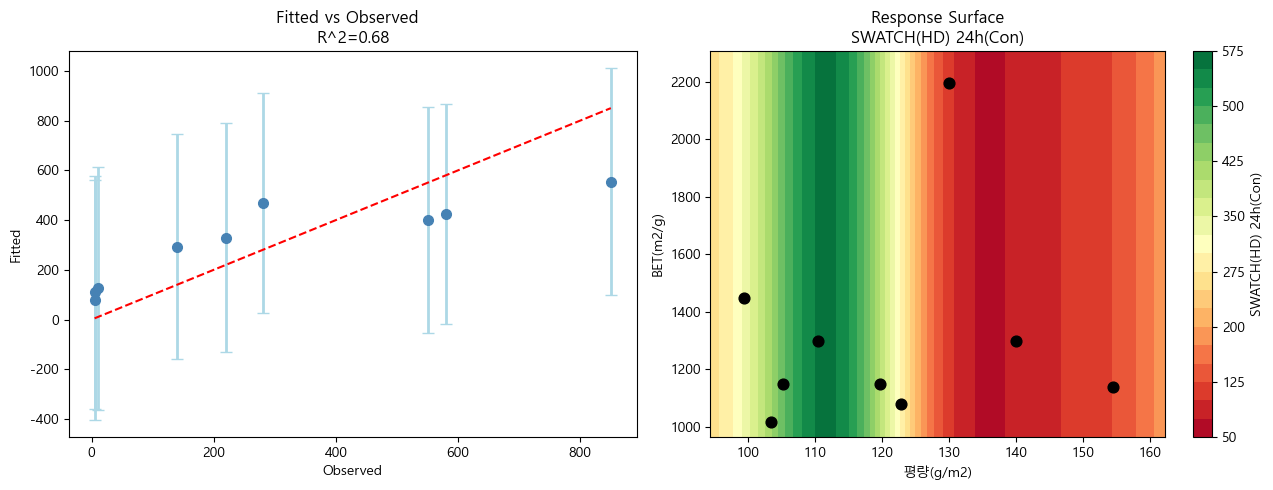

In [78]:
y_HD = df[col_HD].values

res_HD = run_analysis(X_raw, y_HD, col_HD, feat_names, log_y=False)

---
## 4. HD 방호성능 — 로그 변환

  목표 변수: log_HD

[커널 파라미터 (최적화 후)]
  Signal variance (σ²) : 1.1076
  Noise level (σ²_n)   : 0.0659
  SNR                  : 16.81
  log Marginal Likelihood (전체 모델): -8.4961

[특성 유의성 검정]


,특성,ARD length scale,기여도 (%),logLML (전체),logLML (제거 후),ΔlogLML,유의성
0,평량(g/m2),0.8405,85.54,-8.4961,-12.7716,4.2755,*** (유의)
1,BET(m2/g),4.9719,14.46,-8.4961,-8.5947,0.0986,(비유의)


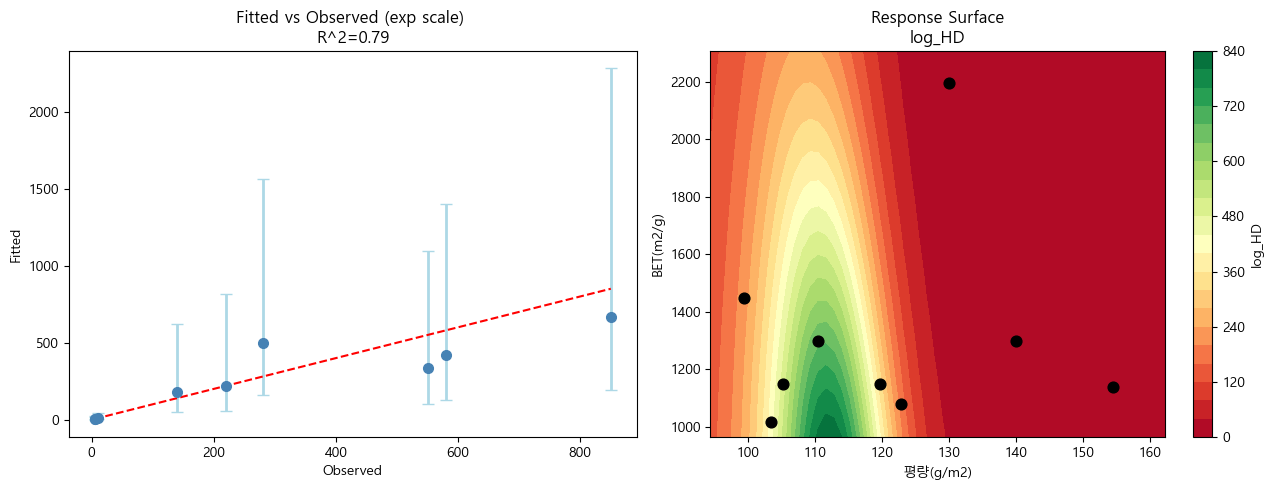

In [79]:
y_logHD = df['log_HD'].values

res_logHD = run_analysis(X_raw, y_logHD, 'log_HD', feat_names, log_y=True)

---
## 5. 종합 유의성 요약

In [80]:
labels = ['GD (raw)', 'GD (log)', 'HD (raw)', 'HD (log)']
all_results = [res_GD, res_logGD, res_HD, res_logHD]

rows = []
for label, res in zip(labels, all_results):
    sig_df = res['sig_df']
    for _, row in sig_df.iterrows():
        rows.append({
            '목표변수':    label,
            '특성':        row['특성'],
            'ΔlogLML':    row['ΔlogLML'],
            '기여도 (%)': row['기여도 (%)'],
            '유의성':      row['유의성']
        })

summary = pd.DataFrame(rows)
print('=== 전체 유의성 요약 ===')
print('ΔlogLML > 3: 유의 (***)  |  1~3: 경계 (*)  |  < 1: 비유의')
display(summary)

=== 전체 유의성 요약 ===
ΔlogLML > 3: 유의 (***)  |  1~3: 경계 (*)  |  < 1: 비유의


,목표변수,특성,ΔlogLML,기여도 (%),유의성
0,GD (raw),평량(g/m2),0.0018,50.00,(비유의)
1,GD (raw),BET(m2/g),0.0000,50.00,(비유의)
2,GD (log),평량(g/m2),0.1750,99.94,(비유의)
3,GD (log),BET(m2/g),-0.0000,0.06,(비유의)
4,HD (raw),평량(g/m2),0.4456,99.95,(비유의)
5,HD (raw),BET(m2/g),-0.0000,0.05,(비유의)
6,HD (log),평량(g/m2),4.2755,85.54,*** (유의)
7,HD (log),BET(m2/g),0.0986,14.46,(비유의)


In [81]:
def plot_uncertainty_band(gpr_full, X_sc, y, y_label, log_y=False):
    y_fit, y_std = gpr_full.predict(X_sc, return_std=True)

    if log_y:
        y_true = np.exp(y)
        y_pred = np.exp(y_fit)
        y_lower = np.exp(y_fit - 1.96 * y_std)
        y_upper = np.exp(y_fit + 1.96 * y_std)
    else:
        y_true = y
        y_pred = y_fit
        y_lower = y_fit - 1.96 * y_std
        y_upper = y_fit + 1.96 * y_std

    order = np.argsort(y_true)

    plt.figure(figsize=(7, 5))

    # 불확실성 영역
    plt.fill_between(
        y_true[order],
        y_lower[order],
        y_upper[order],
        color='pink',
        alpha=0.35,
        label='95% uncertainty'
    )

    # 예측값
    plt.plot(y_true[order], y_pred[order], color='black', linewidth=1.5, label='Fitted')

    # 실제 관측값
    plt.scatter(y_true, y_pred, color='steelblue', edgecolors='black', s=60)

    # y=x 기준선
    lo = min(y_true.min(), y_lower.min())
    hi = max(y_true.max(), y_upper.max())
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1)

    plt.xlabel('Observed')
    plt.ylabel('Fitted')
    plt.title(f'GPR Uncertainty Band: {y_label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

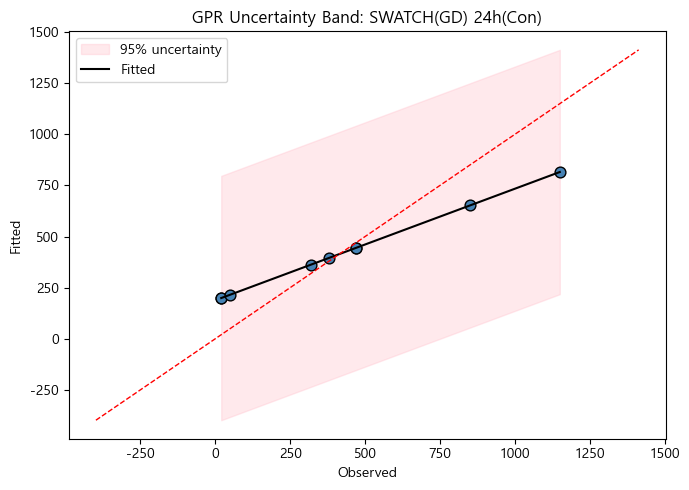

In [82]:
plot_uncertainty_band(
    res_GD['gpr'],
    res_GD['scaler'].transform(X_raw),
    y_GD,
    col_GD,
    log_y=False
)

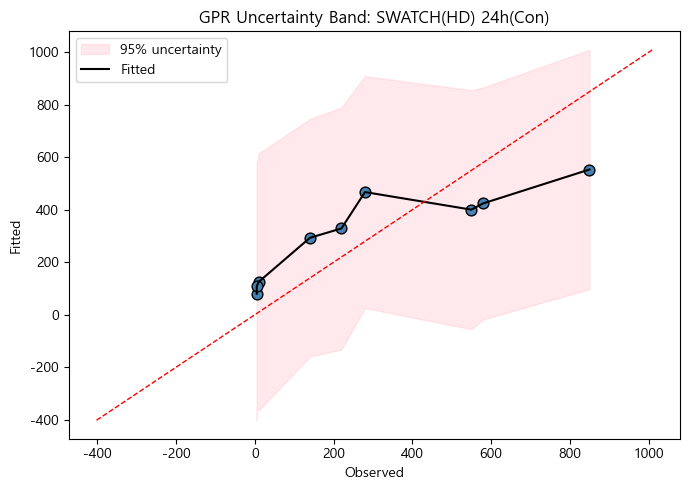

In [83]:
plot_uncertainty_band(
    res_HD['gpr'],
    res_HD['scaler'].transform(X_raw),
    y_HD,
    col_HD,
    log_y=False
)

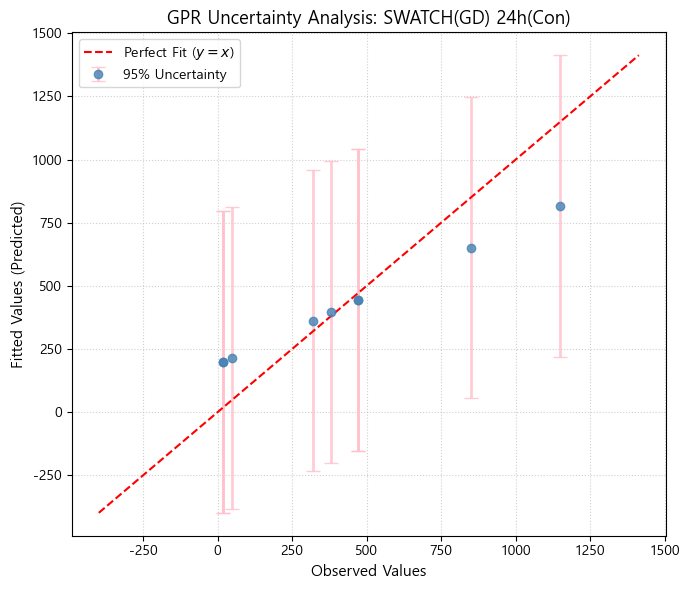

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_uncertainty_scatter(gpr_full, X_sc, y, y_label, log_y=False):
    # 1. 예측값 및 표준편차 획득
    y_fit, y_std = gpr_full.predict(X_sc, return_std=True)

    # 2. 로그 변환 처리
    if log_y:
        y_true = np.exp(y)
        y_pred = np.exp(y_fit)
        # 로그 스케일에서의 95% 구간 계산
        y_lower = np.exp(y_fit - 1.96 * y_std)
        y_upper = np.exp(y_fit + 1.96 * y_std)
    else:
        y_true = y
        y_pred = y_fit
        y_lower = y_fit - 1.96 * y_std
        y_upper = y_fit + 1.96 * y_std

    # 수직 오차 계산 (상한/하한 차이)
    y_err = [y_pred - y_lower, y_upper - y_pred]

    plt.figure(figsize=(7, 6))

    # 3. 오차 막대 그리기 (밴드 대신 이 방식을 쓰면 그래프가 꼬이지 않습니다)
    plt.errorbar(
        y_true, y_pred, yerr=y_err, 
        fmt='o', color='steelblue', ecolor='pink', 
        elinewidth=2, capsize=5, alpha=0.8, label='95% Uncertainty'
    )

    # 4. y=x 기준선 (예측이 완벽할 경우의 선)
    lo = min(y_true.min(), y_lower.min())
    hi = max(y_true.max(), y_upper.max())
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect Fit ($y=x$)')

    plt.xlabel('Observed Values', fontsize=11)
    plt.ylabel('Fitted Values (Predicted)', fontsize=11)
    plt.title(f'GPR Uncertainty Analysis: {y_label}', fontsize=13)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 함수 실행
plot_uncertainty_scatter(
    res_GD['gpr'],
    res_GD['scaler'].transform(X_raw),
    y_GD,
    col_GD,
    log_y=False
)